In [1]:
!pip install -q ultralytics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.8 MB/s eta 0:00:00


In [2]:
import os
import cv2
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

In [3]:
DATASET_ROOT = "/kaggle/input/datasets/kaggleprollc/mapillary-vistas-image-data-collection/Mapillary Vistas"

TRAIN_IMAGES = f"{DATASET_ROOT}/training/images"
TRAIN_LABELS = f"{DATASET_ROOT}/training/v1.2/labels"

VAL_IMAGES = f"{DATASET_ROOT}/validation/images"
VAL_LABELS = f"{DATASET_ROOT}/validation/v1.2/labels"

In [6]:
import shutil
import os

#shutil.rmtree("/kaggle/working/yolo_dataset")

os.makedirs("/kaggle/working/yolo_dataset/images/train", exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/images/val", exist_ok=True)

os.makedirs("/kaggle/working/yolo_dataset/labels/train", exist_ok=True)
os.makedirs("/kaggle/working/yolo_dataset/labels/val", exist_ok=True)

In [7]:
with open(f"{DATASET_ROOT}/config_v1.2.json", "r") as f:
    config = json.load(f)

labels = config["labels"]

for i, label in enumerate(labels):
    print(i, "->", label["readable"])

0 -> Bird
1 -> Ground Animal
2 -> Curb
3 -> Fence
4 -> Guard Rail
5 -> Barrier
6 -> Wall
7 -> Bike Lane
8 -> Crosswalk - Plain
9 -> Curb Cut
10 -> Parking
11 -> Pedestrian Area
12 -> Rail Track
13 -> Road
14 -> Service Lane
15 -> Sidewalk
16 -> Bridge
17 -> Building
18 -> Tunnel
19 -> Person
20 -> Bicyclist
21 -> Motorcyclist
22 -> Other Rider
23 -> Lane Marking - Crosswalk
24 -> Lane Marking - General
25 -> Mountain
26 -> Sand
27 -> Sky
28 -> Snow
29 -> Terrain
30 -> Vegetation
31 -> Water
32 -> Banner
33 -> Bench
34 -> Bike Rack
35 -> Billboard
36 -> Catch Basin
37 -> CCTV Camera
38 -> Fire Hydrant
39 -> Junction Box
40 -> Mailbox
41 -> Manhole
42 -> Phone Booth
43 -> Pothole
44 -> Street Light
45 -> Pole
46 -> Traffic Sign Frame
47 -> Utility Pole
48 -> Traffic Light
49 -> Traffic Sign (Back)
50 -> Traffic Sign (Front)
51 -> Trash Can
52 -> Bicycle
53 -> Boat
54 -> Bus
55 -> Car
56 -> Caravan
57 -> Motorcycle
58 -> On Rails
59 -> Other Vehicle
60 -> Trailer
61 -> Truck
62 -> Wheeled

In [8]:
FINAL_CLASSES = {
    "road": 0,
    "person": 1,
    "vehicle": 2,
    "bicycle": 3,
}

In [9]:
CLASS_MAP = {

    # ROAD
    13: 0,

    # PERSON
    19: 1,

    # VEHICLES
    54: 2,   # bus
    55: 2,   # car
    57: 2,   # motorcycle
    59: 2,   # other vehicle
    61: 2,   # truck

    # BICYCLE + RIDERS
    20: 3,   # bicyclist
    52: 3,   # bicycle

}

In [10]:
COLOR_MAP = {}

for old_id, new_id in CLASS_MAP.items():

    color = labels[old_id]["color"]

    COLOR_MAP[tuple(color)] = new_id

print(COLOR_MAP)

{(128, 64, 128): 0, (220, 20, 60): 1, (0, 60, 100): 2, (0, 0, 142): 2, (0, 0, 230): 2, (128, 64, 64): 2, (0, 0, 70): 2, (255, 0, 0): 3, (119, 11, 32): 3}


In [12]:
def mask_to_polygons(mask, class_id):

    binary = np.uint8(mask == class_id)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    polygons = []

    for contour in contours:

        if len(contour) < 3:
            continue

        contour = contour.squeeze()

        if len(contour.shape) != 2:
            continue

        area = cv2.contourArea(contour)

        if area < 200:    #20
            continue

        epsilon = 0.002 * cv2.arcLength(contour, True)   #0.002

        approx = cv2.approxPolyDP(
            contour,
            epsilon,
            True
        )

        polygons.append(approx.squeeze())

    return polygons

In [13]:
def convert_split(split="training"):

    TARGET_SIZE = (1280, 960)

    if split == "training":

        image_dir = TRAIN_IMAGES
        label_dir = TRAIN_LABELS

        out_img = "/kaggle/working/yolo_dataset/images/train"
        out_lbl = "/kaggle/working/yolo_dataset/labels/train"

    else:

        image_dir = VAL_IMAGES
        label_dir = VAL_LABELS

        out_img = "/kaggle/working/yolo_dataset/images/val"
        out_lbl = "/kaggle/working/yolo_dataset/labels/val"

    images = sorted(glob(image_dir + "/*.jpg"))[:2500]

    for img_path in tqdm(images):

        name = os.path.basename(img_path).replace(".jpg", "")

        label_path = f"{label_dir}/{name}.png"

        if not os.path.exists(label_path):
            continue

#LOAD_IMAGE

        image = cv2.imread(img_path)

        image = cv2.resize(
            image,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

#LOAD_RGB_MASK

        mask_rgb = cv2.imread(label_path)

        mask_rgb = cv2.cvtColor(
            mask_rgb,
            cv2.COLOR_BGR2RGB
        )

#RESIZING_MASKS

        mask_rgb = cv2.resize(
            mask_rgb,
            TARGET_SIZE,
            interpolation=cv2.INTER_NEAREST
        )

#CREATING_CLASS_ID_MASK

        mask = np.zeros(
            (mask_rgb.shape[0], mask_rgb.shape[1]),
            dtype=np.uint8
        )

        for color, class_id in COLOR_MAP.items():

            matches = np.all(
                mask_rgb == color,
                axis=-1
            )

            mask[matches] = class_id

        h, w = mask.shape

        txt_lines = []

#POLYGON_EXTRACTION

        for class_id in np.unique(mask):
            if class_id not in [0, 1, 2, 3]:
                continue

            #if class_id == 0:
                #continue

            polygons = mask_to_polygons(
                mask,
                class_id
            )

            for poly in polygons:

                poly = poly.astype(np.float32)

                poly[:, 0] /= w
                poly[:, 1] /= h

                poly = poly.flatten()

                if len(poly) < 6:
                    continue

                line = (
                    str(class_id)
                    + " "
                    + " ".join(map(str, poly))
                )

                txt_lines.append(line)

  #SAVE_RESIZED_IMG  

        cv2.imwrite(
            f"{out_img}/{name}.jpg",
            image
        )

#SAVE LABELS

        with open(
            f"{out_lbl}/{name}.txt",
            "w"
        ) as f:

            f.write("\n".join(txt_lines))

In [14]:
convert_split("training")
convert_split("validation")

100%|██████████| 2000/2000 [14:52<00:00,  2.24it/s]


In [15]:
from glob import glob

label_files = glob(
    "/kaggle/working/yolo_dataset/labels/train/*.txt"
)

print("Total label files:", len(label_files))

sample_file = label_files[0]

print(open(sample_file).read()[:1000])

Total label files: 2500
0 0.0 0.0 0.0 0.99895835 0.99921876 0.99895835 0.99921876 0.0
2 0.5765625 0.5072917 0.57421875 0.5072917 0.5734375 0.5083333 0.56875 0.5083333 0.5671875 0.5052083 0.5671875 0.49791667 0.56328124 0.49479166 0.56171876 0.49479166 0.5609375 0.49375 0.55 0.49375 0.5492188 0.49479166 0.5445312 0.49583334 0.54296875 0.49791667 0.54296875 0.503125 0.5421875 0.50416666 0.5375 0.50416666 0.53515625 0.50625 0.5335938 0.503125 0.5257813 0.503125 0.525 0.50208336 0.52421874 0.503125 0.51171875 0.503125 0.5109375 0.50416666 0.50859374 0.50416666 0.50859374 0.50625 0.5078125 0.5072917 0.503125 0.50625 0.5015625 0.5072917 0.5015625 0.509375 0.5023438 0.5104167 0.5015625 0.51458335 0.503125 0.51354164 0.5054687 0.51354164 0.5078125 0.515625 0.5078125 0.5229167 0.50859374 0.5239583 0.509375 0.5239583 0.5109375 0.5208333 0.5125 0.521875 0.5132812 0.53125 0.5140625 0.53229165 0.51640624 0.53229165 0.51640624 0.53020835 0.5171875 0.52916664 0.53125 0.52916664 0.5328125 0.53229165 0

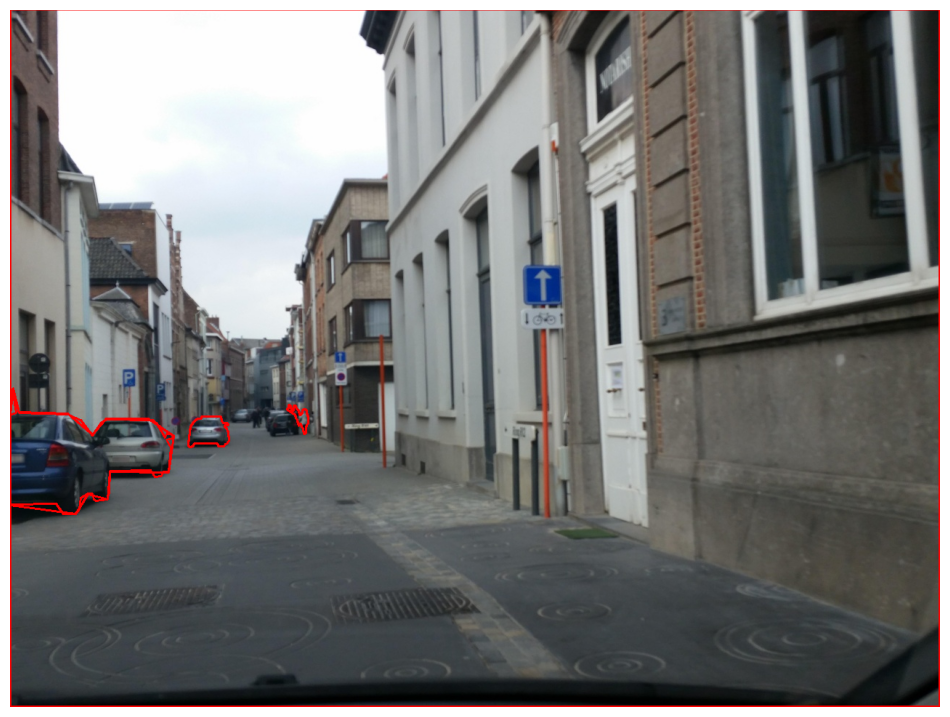

In [16]:
sample_image = glob(
    "/kaggle/working/yolo_dataset/images/train/*.jpg"
)[0]

sample_label = sample_image.replace(
    "/images/",
    "/labels/"
).replace(".jpg", ".txt")

image = cv2.imread(sample_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(sample_label, "r") as f:
    lines = f.readlines()

for line in lines:

    parts = line.strip().split()

    cls = int(parts[0])

    coords = np.array(parts[1:], dtype=np.float32)

    coords[0::2] *= w
    coords[1::2] *= h

    pts = coords.reshape(-1,2).astype(np.int32)

    cv2.polylines(
        image,
        [pts],
        True,
        (255,0,0),
        2
    )

plt.figure(figsize=(12,12))
plt.imshow(image)
plt.axis("off")
plt.show()

In [17]:
yaml_text = """
path: /kaggle/working/yolo_dataset

train: images/train
val: images/val

names:
  0: drivable
  1: person
  2: vehicle
  3: bicycle
"""

with open("/kaggle/working/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_text)

In [19]:
from ultralytics import YOLO

model = YOLO("yolo26s-seg.pt")

results = model.train(

    data="/kaggle/working/yolo_dataset/data.yaml",

    epochs=50,

    imgsz=768,

    batch=6,

    device=0,

    workers=4,

    cache=True,

    amp=True,

    overlap_mask=False,

    optimizer="AdamW",

    lr0=1e-3,

    weight_decay=1e-4,

    warmup_epochs=3,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    translate=0.1,
    scale=0.3,
    fliplr=0.5,

    mosaic=0.2, #0.5

    pretrained=True,

    patience=15
)

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-seg.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=False, 

In [23]:
from ultralytics import YOLO

model = YOLO(
    "/kaggle/working/runs/segment/train-2/weights/best.pt"
)

In [24]:
from glob import glob

sample_images = glob(
    "/kaggle/working/yolo_dataset/images/val/*.jpg"
)[:10]

results = model.predict(

    source=sample_images,

    imgsz=768,

    conf=0.10,

    retina_masks=True,

    save=True
)


0: 576x768 13 vehicles, 17.9ms
1: 576x768 4 persons, 7 vehicles, 17.9ms
2: 576x768 2 vehicles, 17.9ms
3: 576x768 4 persons, 4 vehicles, 17.9ms
4: 576x768 1 drivable, 5 vehicles, 17.9ms
5: 576x768 3 persons, 3 vehicles, 17.9ms
6: 576x768 3 vehicles, 17.9ms
7: 576x768 1 person, 10 vehicles, 17.9ms
8: 576x768 4 persons, 13 vehicles, 17.9ms
9: 576x768 2 persons, 4 vehicles, 17.9ms
Speed: 3.1ms preprocess, 17.9ms inference, 2.5ms postprocess per image at shape (1, 3, 576, 768)
Results saved to /kaggle/working/runs/segment/predict-2


Total predictions: 10


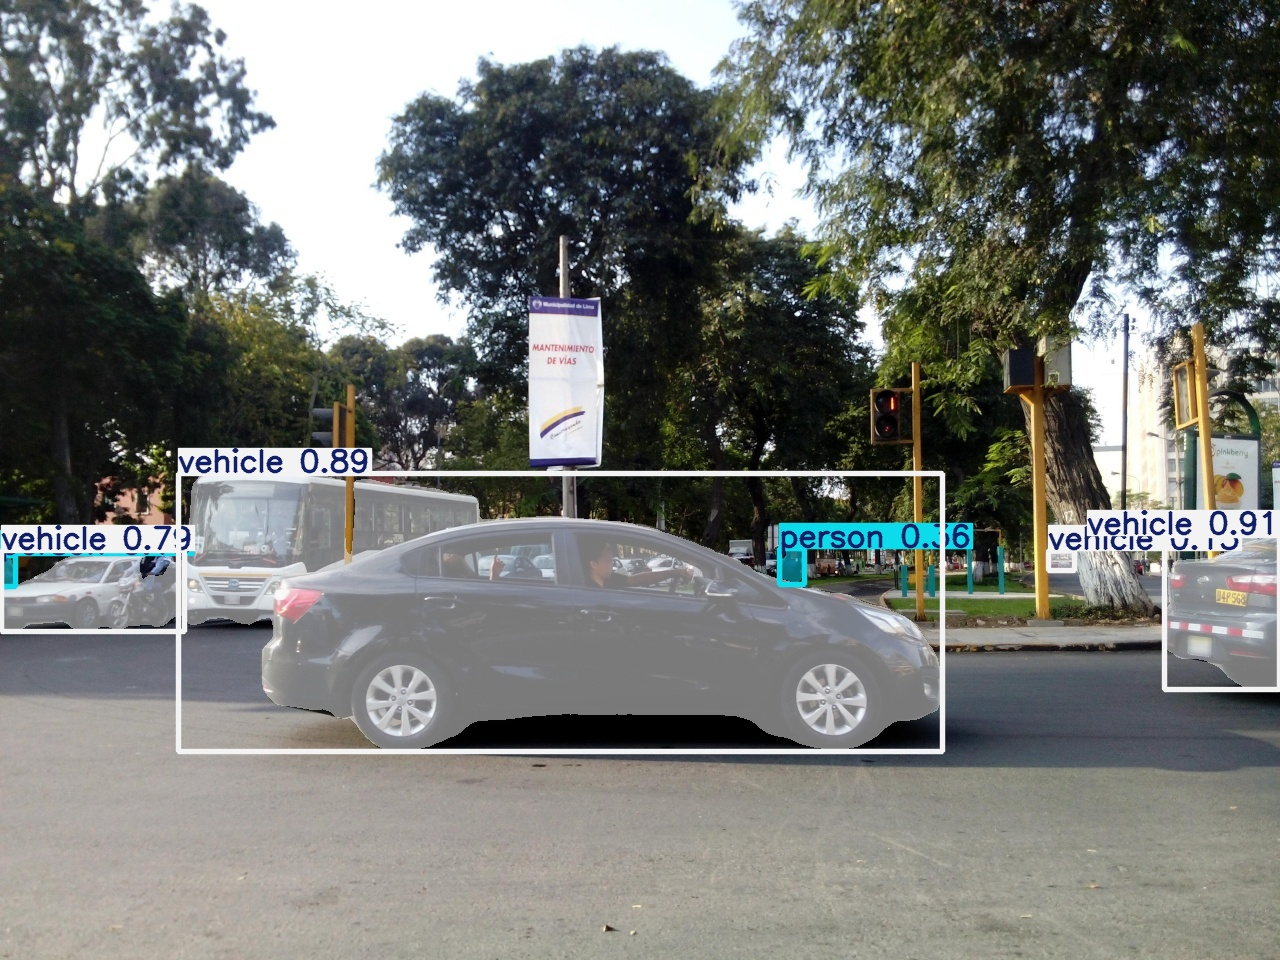

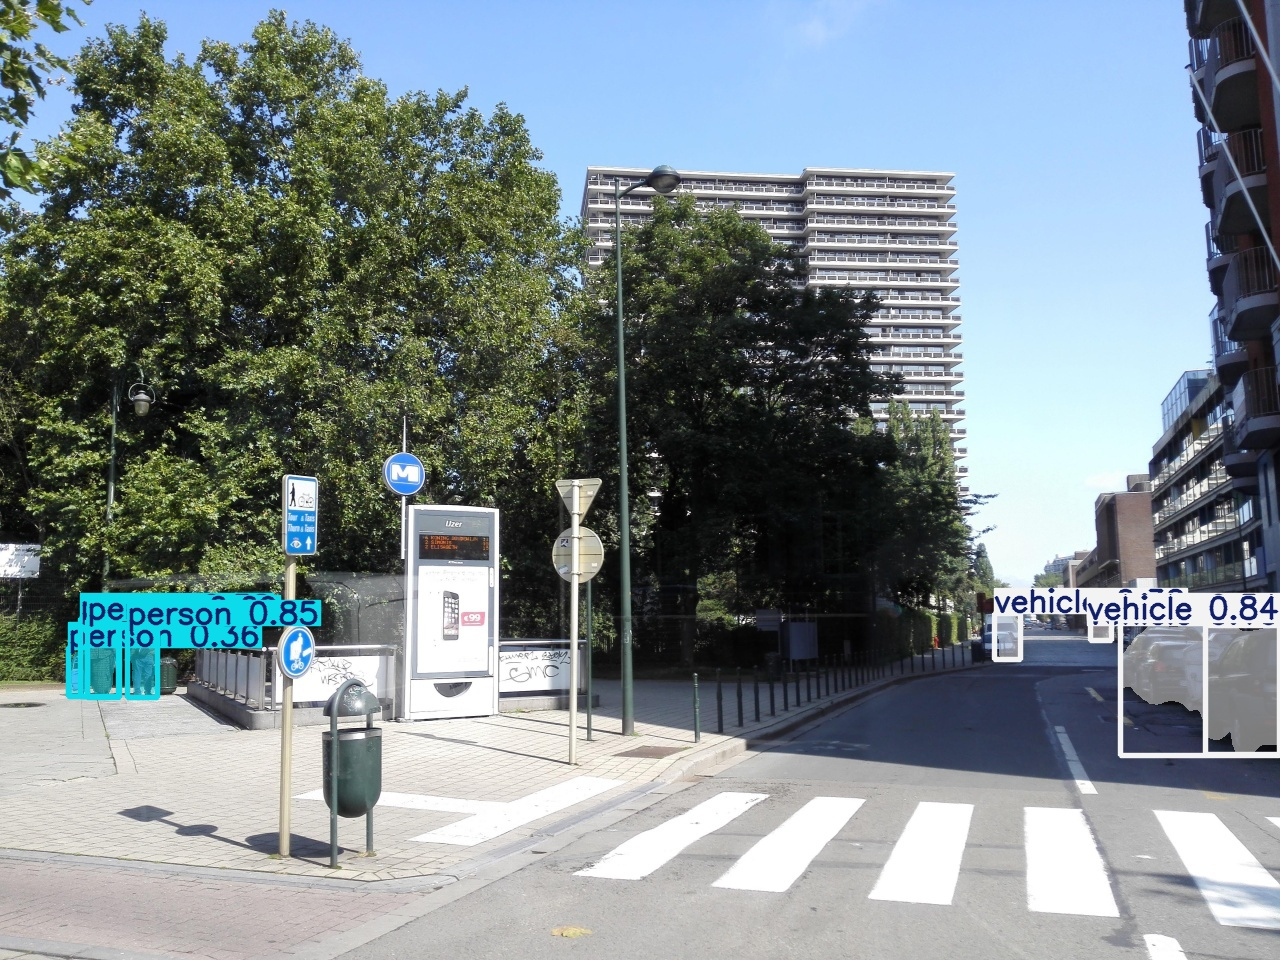

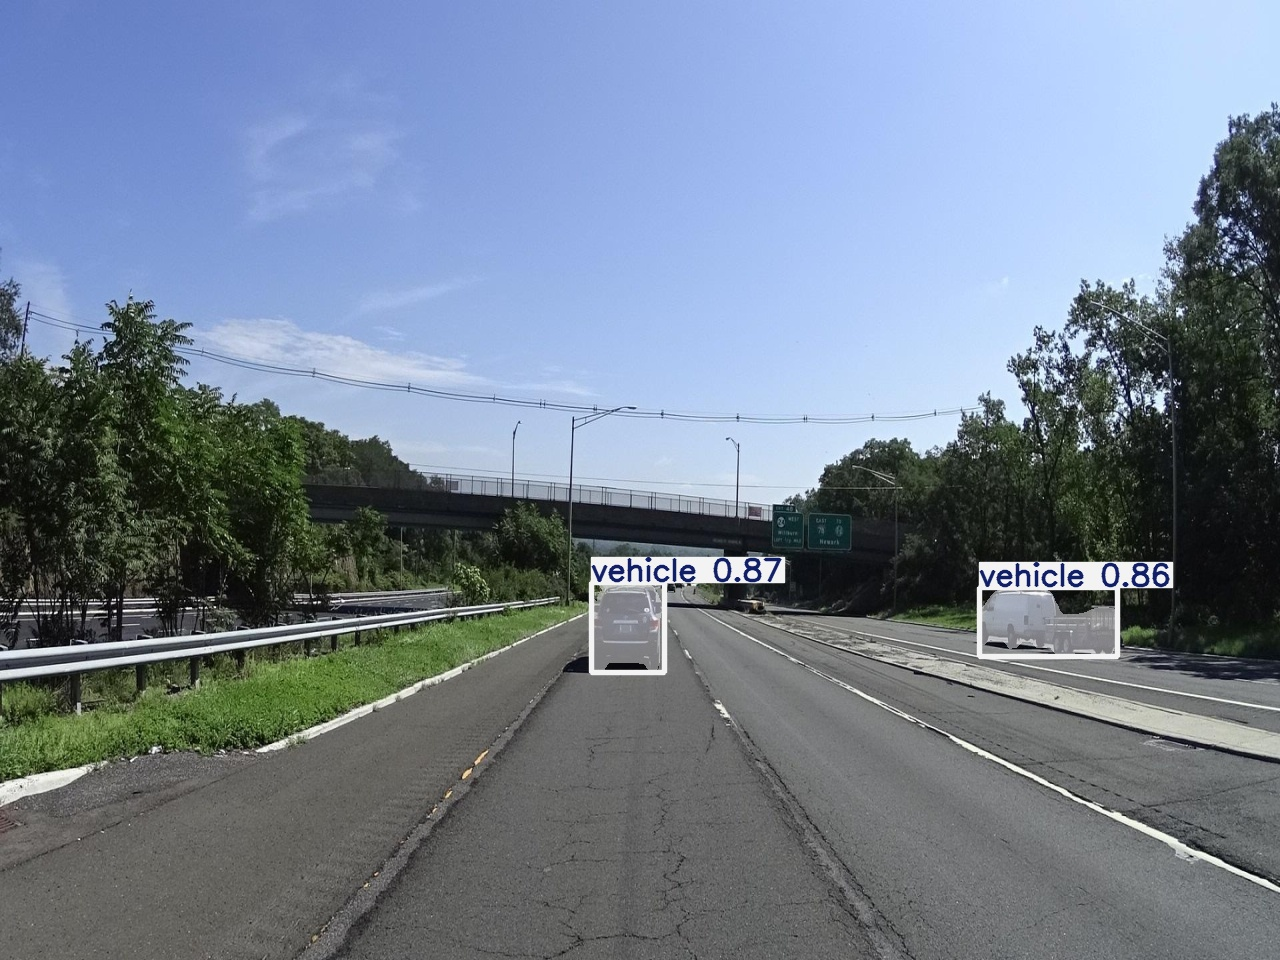

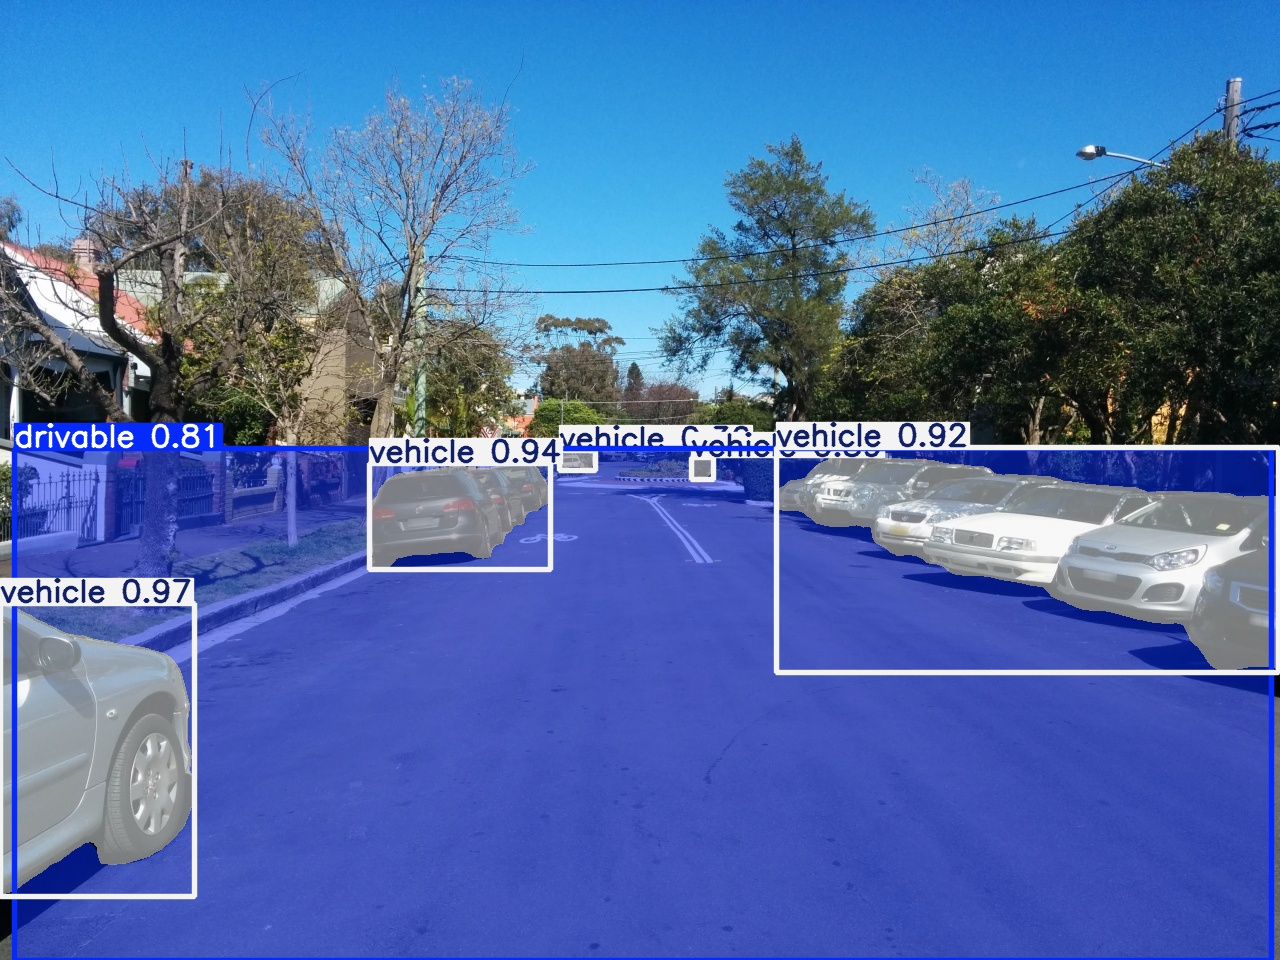

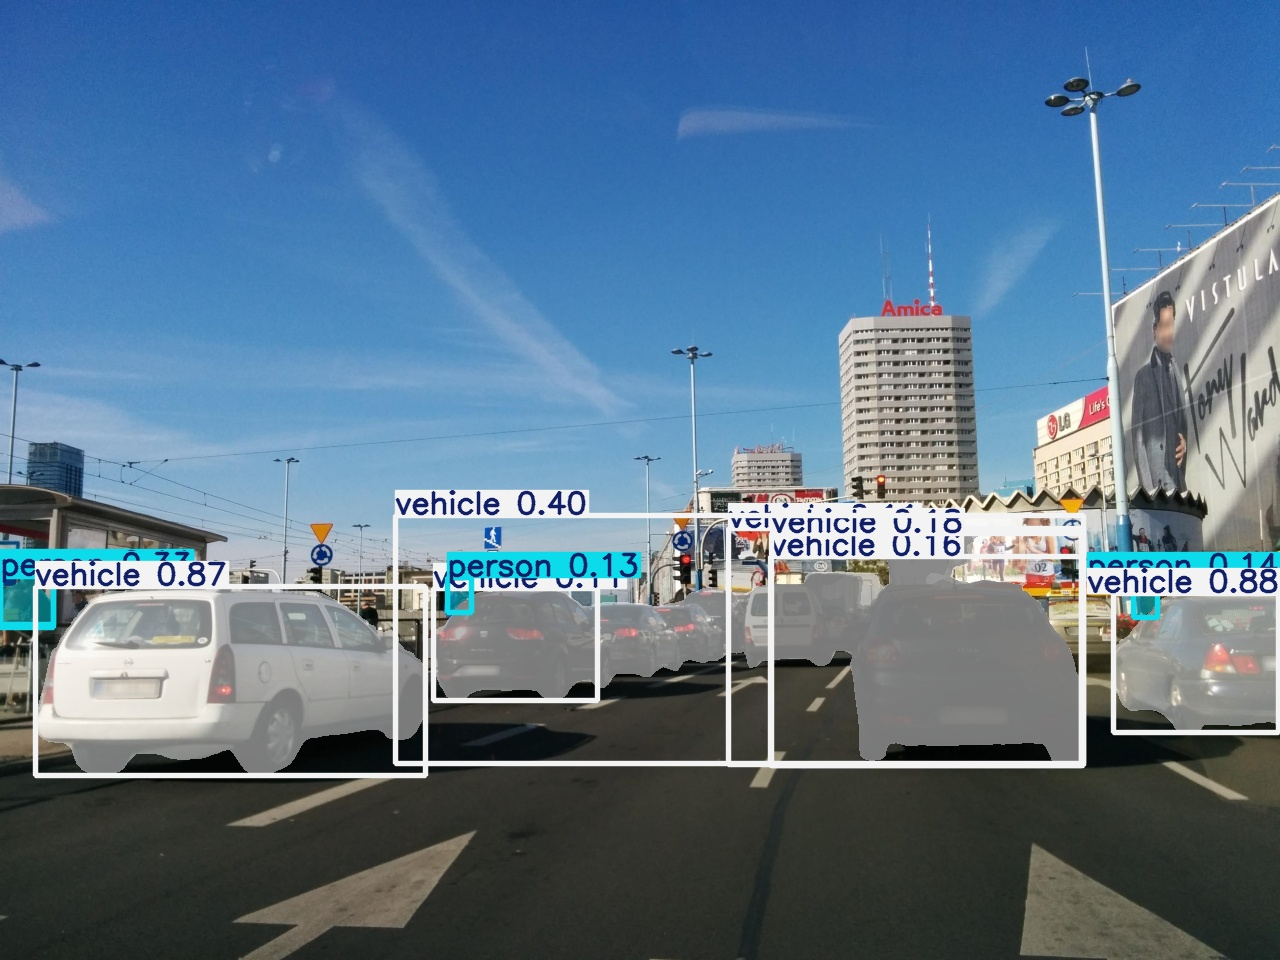

In [25]:
from IPython.display import Image, display
from glob import glob

preds = glob(
    "/kaggle/working/runs/segment/predict/*.jpg"
)

print("Total predictions:", len(preds))

for img in preds[:5]:

    display(Image(filename=img))

In [26]:
metrics = model.val()

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3367.1±979.7 MB/s, size: 371.4 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 699.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 2.7it/s 46.0s0.3s
                   all       2000      12495      0.741      0.638      0.684      0.528      0.741      0.622      0.665      0.466
              drivable       2000       2088      0.984      0.959       0.97      0.961      0.984      0.958      0.972      0.919
                person        805       2507      0.701      0.564       0.64      0.373       0.68      0.528      0.592      0.288
               vehicle       1844       7442      0.737      0.716      0.769      0.561      0.738      0.70

In [40]:
model.export(format="saved_model")

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/segment/train-2/weights/best.pt' with input shape (1, 3, 768, 768) BCHW and output shape(s) ((1, 300, 38), (1, 32, 192, 192)) (22.3 MB)

ONNX: starting export with onnx 1.20.1 opset 20...


KeyboardInterrupt: 

In [28]:
import os

os.listdir(
    "/kaggle/working/runs/segment/train-2/weights"
)

['best.onnx', 'best.pt', 'last.pt', 'best_saved_model']

In [30]:
import tensorflow as tf

tf_model = tf.saved_model.load(
    "/kaggle/working/runs/segment/train-2/weights/best_saved_model"
)

print(tf_model.signatures.keys())

KeysView(_SignatureMap({'serving_default': <ConcreteFunction (*, images: TensorSpec(shape=(1, 768, 768, 3), dtype=tf.float32, name='images')) -> Dict[['output_1', TensorSpec(shape=(1, 192, 192, 32), dtype=tf.float32, name='output_1')], ['output_0', TensorSpec(shape=(1, 300, 38), dtype=tf.float32, name='output_0')]] at 0x799E67817EC0>}))


In [31]:
import shutil

shutil.make_archive(
    "/kaggle/working/final_model",
    'zip',
    "/kaggle/working/runs"
)

'/kaggle/working/final_model.zip'

In [32]:
import os

for f in os.listdir("/kaggle/working"):
    print(f)

calibration_image_sample_data_20x128x128x3_float32.npy
final_model.zip
runs
.virtual_documents
yolo26s-seg.pt
yolo_dataset
yolo26n.pt


In [35]:
import shutil

shutil.make_archive(
    "/kaggle/working/model_weights",
    'zip',
    "/kaggle/working/runs/segment/train-2/weights"
)

print("DONE")

DONE


In [36]:
import os

print(os.listdir("/kaggle/working"))

['calibration_image_sample_data_20x128x128x3_float32.npy', 'model_weights.zip', 'final_model.zip', 'runs', '.virtual_documents', 'yolo26s-seg.pt', 'yolo_dataset', 'yolo26n.pt']


In [39]:
from IPython.display import FileLink

FileLink("/kaggle/working/final_model.zip")

/kaggle/working/final_model.zip